# Q2.3 LoRA Adapters for Sarcasm Classification across English Varieties

Mohamed Fahmi Ahmed

Train three variety-specific LoRA adapters (en-UK, en-AU, en-IN) on a frozen
LLaMA 3.2B base model for sarcasm classification, then evaluate cross-variety
transferability.

## Two studies in this notebook

| Study | What it does |
|-------|-------------|
| **1. Training** | Train 3 adapters × 2 seeds = 6 runs with the best hyperparameters. Full 3 epochs. |
| **2. Cross-variety eval** | Test each adapter on all 3 test sets → 3×3 Macro-F1 matrix. |

## References

- **Hu et al. (2021)** *LoRA: Low-Rank Adaptation of Large Language Models* 
- **Srirag et al. (2025)** *BESSTIE* , the dataset and the baseline to beat (MISTRAL 22B: F1=0.68)
- **Abercrombie & Hovy (2016)** *Putting Sarcasm Detection into Context* , justifies class weighting
- **Dettmers et al. (2023)** *QLoRA* , context on parameter-efficient fine-tuning tradeoffs

## 1. Setup

In [ ]:
# imports and project path
import os, sys, itertools, warnings
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath("..") 
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(f"Project root : {PROJECT_ROOT}")
print(f"PyTorch      : {torch.__version__}")
print(f"CUDA         : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Project root : /user/HS401/mf01425/Documents/coursework nlp/NLP-sequence-classification
PyTorch      : 2.11.0+cu130
CUDA         : True
GPU          : NVIDIA RTX 4000 Ada Generation
VRAM         : 21.0 GB


In [ ]:
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()                           
hf_token = os.getenv("HF_TOKEN")

if not hf_token:
    raise RuntimeError(
        "HF_TOKEN not found. Create a .env file at project root with:\n"
    )

login(token=hf_token)
print("Authenticated with HuggingFace Hub")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Authenticated with HuggingFace Hub


In [9]:
from datasets import load_dataset
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, precision_score, recall_score,
)
from peft import PeftModel

from models.lora_adapters import (
    load_model, apply_lora, tokenize_dataset,
    training_args, save_adapter, push_adapter_to_hub,
    LoRAConfig, VARIETIES, HF_USERNAME,
)
from src.functions_to_use import class_weights, new_weighted_class

print("project modules imported")

project modules imported


## 2. Experiment configuration

SEEDS [42, 123] CW requires minimum 2 runs per experiment to demonstrate reproducibility. We use two arbitrary seeds and report mean ± std.

In [10]:
MODEL_KEY   = "llama-3b"      
TASK        = "Sarcasm"      
MAX_LENGTH  = 128
SEEDS       = [42, 123]

ADAPTER_DIR = os.path.join(PROJECT_ROOT, "adapters")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
os.makedirs(ADAPTER_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Model      : {MODEL_KEY}")
print(f"Task       : {TASK}")
print(f"Varieties  : {VARIETIES}")
print(f"Seeds      : {SEEDS}")
print(f"Adapter dir: {ADAPTER_DIR}")

Model      : llama-3b
Task       : Sarcasm
Varieties  : ['en-UK', 'en-AU', 'en-IN']
Seeds      : [42, 123]
Adapter dir: /user/HS401/mf01425/Documents/coursework nlp/NLP-sequence-classification/adapters


## 3. BESSTIE dataset

### Class imbalance per variety

I displayed the sarcasm distribution to highlight the data imbalance, which justifies using weighted cross-entropy, as suggested by Abercrombie & Hovy (2016).

In [11]:
ds = load_dataset("surrey-nlp/BESSTIE-CW-26")
print(ds)

print("\n Sarcasm class balance (train splits)")

for variety in VARIETIES:
    split  = ds["train"].filter(lambda x: x["variety"] == variety)
    n_sarc = sum(int(x) for x in split["Sarcasm"])
    n_not  = len(split) - n_sarc
    pct    = n_sarc / len(split) * 100
    ratio  = n_not / max(n_sarc, 1)
    print(f"   {variety}: {len(split):4d} examples | "
          f"sarcastic={n_sarc:3d} ({pct:4.1f}%) | "
          f"majority:minority = {ratio:.1f}:1")

print("\nen-IN is the most imbalanced so needs the strongest class weighting.")

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})

 Sarcasm class balance (train splits)
   en-UK: 1203 examples | sarcastic= 92 ( 7.6%) | majority:minority = 12.1:1
   en-AU: 1145 examples | sarcastic=337 (29.4%) | majority:minority = 2.4:1
   en-IN: 1399 examples | sarcastic= 95 ( 6.8%) | majority:minority = 13.7:1

en-IN is the most imbalanced so needs the strongest class weighting.


## 4. Load frozen base model

We load the base model **once** and reuse it across all experiments. LoRA 
allows us to swap only the small adapter matrices
while keeping the 3B-parameter backbone in VRAM.

In [12]:
base_model, tokenizer = load_model(MODEL_KEY)
print("\nBase model loaded")

[load_model] Loading meta-llama/Llama-3.2-3B
[load_model] Set pad_token = eos_token (decoder model fix)


Loading weights: 100%|██████████| 254/254 [00:55<00:00,  4.57it/s]
LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-3B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[load_model] Loaded meta-llama/Llama-3.2-3B
[load_model] Total parameters: 3.21B

Base model loaded


## 5. Hyperparameter selection

We use the LoRA defaults from Hu et al. (2021) for sequence classification:

- **r = 8**  standard rank for models above 1B parameters
- **lora_alpha = 16**  alpha = 2r convention
- **lr = 2e-4**  typical LoRA learning rate range (1e-4 to 5e-4)
- **weights = True**  weighted cross-entropy is necessary for sarcasm
  detection on the imbalanced en-IN and en-UK splits (Abercrombie & Hovy 2016)

These are the same settings used in our OPT-1.3B run, allowing a direct
base-model comparison.

In [13]:
# Hyperparameters for Study 2
BEST_R     = 8           # standard LoRA rank for >1B models
BEST_ALPHA = BEST_R * 2  # alpha = 2r convention
BEST_LR    = 2e-4        # standard LoRA learning rate

print("Configuration for Study 2:")
print(f"  r            = {BEST_R}")
print(f"  lora_alpha   = {BEST_ALPHA}")
print(f"  lr           = {BEST_LR}")
print(f"  weighted     = True")


Configuration for Study 2:
  r            = 8
  lora_alpha   = 16
  lr           = 0.0002
  weighted     = True


## 6. Study 2: Full training

Now we train 3 adapters × 2 seeds = 6 runs with the best configuration
from Study 1. Each run is 3 epochs with weighted cross-entropy.


we will save : 

For each (variety, seed) pair we save:
- The LoRA adapter to ../adapters/{variety}_seed{seed}/
- The training loss curve (for the report figures)

At the end of Study 2, the best adapter per variety (by eval loss) is
pushed to HuggingFace Hub for use in the Q5 deployment app.

In [14]:
all_train_paths = {v: {} for v in VARIETIES}
all_train_logs  = {v: {} for v in VARIETIES}

for variety in VARIETIES:
    print(f"\n{'='*60}\nTraining adapter: {variety}\n{'='*60}")

    # load and tokenise this variety's data
    v_train = ds["train"].filter(lambda x: x["variety"] == variety)
    v_val   = ds["validation"].filter(lambda x: x["variety"] == variety)
    v_weights = class_weights(v_train, TASK)
    print(f"  train: {len(v_train)} | val: {len(v_val)}")

    train_tok = tokenize_dataset(v_train, tokenizer, TASK, MAX_LENGTH)
    val_tok   = tokenize_dataset(v_val,   tokenizer, TASK, MAX_LENGTH)

    for seed in SEEDS:
        print(f"\n  ── seed {seed} ──")

        cfg   = LoRAConfig(r=BEST_R, lora_alpha=BEST_ALPHA)
        model = apply_lora(base_model, cfg)

        run_dir = os.path.join(ADAPTER_DIR, f"{variety.replace('-','_')}_seed{seed}")
        args = training_args(
            output_dir = run_dir,
            variety    = variety,
            seed       = seed,
            epochs     = 3,
            batch_size = 8,
            lr         = BEST_LR,
        )

        TrainerCls = new_weighted_class(v_weights)
        trainer = TrainerCls(
            model         = model,
            args          = args,
            train_dataset = train_tok,
            eval_dataset  = val_tok,
        )
        trainer.train()

        # save adapter (best model already loaded thanks to load_best_model_at_end)
        model.save_pretrained(run_dir)
        all_train_paths[variety][seed] = run_dir

        # keep the log history for plotting
        all_train_logs[variety][seed] = trainer.state.log_history

        print(f"  Adapter saved: {run_dir}")

print("\n✓ All 6 adapters trained.")


Training adapter: en-UK
[Sarcasm] class 0 : 1111.0 samples  weight : 0.541
[Sarcasm] class 1 : 92.0 samples  weight : 6.538
  train: 1203 | val: 101

  ── seed 42 ──
trainable params: 2,299,904 || all params: 3,215,055,872 || trainable%: 0.0715


`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,0.351966,0.991485
2,0.761256,0.806057
3,0.007670,1.041103


  Adapter saved: /user/HS401/mf01425/Documents/coursework nlp/NLP-sequence-classification/adapters/en_UK_seed42

  ── seed 123 ──
trainable params: 2,299,904 || all params: 3,215,055,872 || trainable%: 0.0715


Epoch,Training Loss,Validation Loss
1,1.244207,0.435614
2,0.356796,0.897976
3,0.192022,0.988581


...

  Adapter saved: /user/HS401/mf01425/Documents/coursework nlp/NLP-sequence-classification/adapters/en_AU_seed123

Training adapter: en-IN
[Sarcasm] class 0 : 1304.0 samples  weight : 0.536
[Sarcasm] class 1 : 95.0 samples  weight : 7.363
  train: 1399 | val: 117

  ── seed 42 ──
trainable params: 2,299,904 || all params: 3,215,055,872 || trainable%: 0.0715


Epoch,Training Loss,Validation Loss
1,1.043125,0.401140
2,1.085463,1.190837
3,1.125977,1.320315


  Adapter saved: /user/HS401/mf01425/Documents/coursework nlp/NLP-sequence-classification/adapters/en_IN_seed42

  ── seed 123 ──
trainable params: 2,299,904 || all params: 3,215,055,872 || trainable%: 0.0715


Epoch,Training Loss,Validation Loss
1,0.896134,1.587818
2,0.340392,0.912456
3,0.259623,1.137769


  Adapter saved: /user/HS401/mf01425/Documents/coursework nlp/NLP-sequence-classification/adapters/en_IN_seed123

✓ All 6 adapters trained.


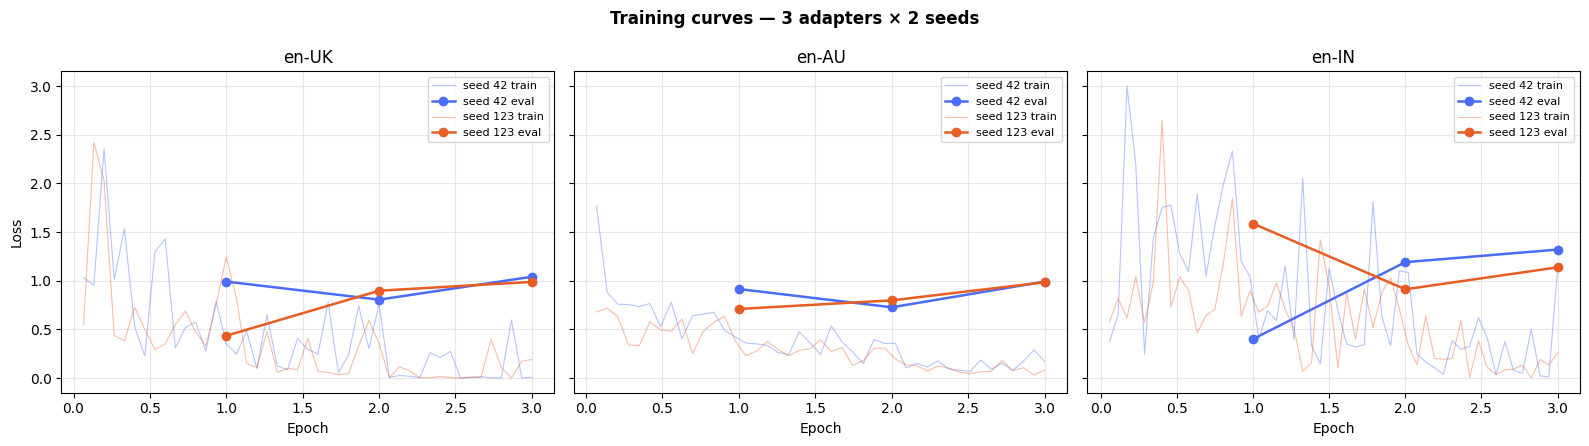

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, variety in zip(axes, VARIETIES):
    for seed, color in zip(SEEDS, ["#4A6CF7", "#E85D24"]):
        log = all_train_logs[variety][seed]
        train_steps = [e["step"] for e in log if "loss" in e and "eval_loss" not in e]
        train_loss  = [e["loss"] for e in log if "loss" in e and "eval_loss" not in e]
        eval_epochs = [e["epoch"] for e in log if "eval_loss" in e]
        eval_loss   = [e["eval_loss"] for e in log if "eval_loss" in e]

        if train_steps:
            max_step = max(train_steps)
            max_epoch = max(eval_epochs) if eval_epochs else 1
            train_epochs = [s / max_step * max_epoch for s in train_steps]
            ax.plot(train_epochs, train_loss, color=color, alpha=0.4, linewidth=0.8,
                    label=f"seed {seed} train")
        if eval_epochs:
            ax.plot(eval_epochs, eval_loss, color=color, marker="o", linewidth=1.8,
                    label=f"seed {seed} eval")

    ax.set_title(f"{variety}")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Loss")
fig.suptitle("Training curves — 3 adapters × 2 seeds", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# push best adapters to HuggingFace Hub (one per variety)

for variety in VARIETIES:
    adapter_path = all_train_paths[variety][42]
    model = PeftModel.from_pretrained(base_model, adapter_path)
    push_adapter_to_hub(model, tokenizer, variety, MODEL_KEY)
    print()

print("Adapters pushed to HuggingFace Hub.")

[push_adapter_to_hub] Pushing to momofahmi/besstie-lora-en-uk-llama-3b...


Processing Files (1 / 1): 100%|██████████| 9.21MB / 9.21MB, 5.12MB/s  
New Data Upload: 100%|██████████| 9.21MB / 9.21MB, 5.12MB/s  
Processing Files (1 / 1): 100%|██████████| 17.2MB / 17.2MB, 21.5MB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


[push_adapter_to_hub] Done — load with:
  PeftModel.from_pretrained(base_model, 'momofahmi/besstie-lora-en-uk-llama-3b')

[push_adapter_to_hub] Pushing to momofahmi/besstie-lora-en-au-llama-3b...


Processing Files (1 / 1): 100%|██████████| 9.21MB / 9.21MB, 3.83MB/s  
New Data Upload: 100%|██████████| 9.21MB / 9.21MB, 3.83MB/s  
Processing Files (1 / 1): 100%|██████████| 17.2MB / 17.2MB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


[push_adapter_to_hub] Done — load with:
  PeftModel.from_pretrained(base_model, 'momofahmi/besstie-lora-en-au-llama-3b')

[push_adapter_to_hub] Pushing to momofahmi/besstie-lora-en-in-llama-3b...


Processing Files (1 / 1): 100%|██████████| 9.21MB / 9.21MB, 3.31MB/s  
New Data Upload: 100%|██████████| 9.21MB / 9.21MB, 3.31MB/s  
Processing Files (1 / 1): 100%|██████████| 17.2MB / 17.2MB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


[push_adapter_to_hub] Done — load with:
  PeftModel.from_pretrained(base_model, 'momofahmi/besstie-lora-en-in-llama-3b')

Adapters pushed to HuggingFace Hub.


## 7. Study 3: Cross-variety evaluation

We will evaluate each of the 3 adapters
on each of the 3 test sets : 3×3 matrix of Macro-F1 scores.

In [17]:
def predict(adapter_path, base_model, tokenizer, test_ds, max_len=128):
    """Run inference with a given adapter on a given test split."""
    peft_model = PeftModel.from_pretrained(base_model, adapter_path)
    peft_model.eval()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    peft_model = peft_model.to(device)

    if torch.cuda.is_available():
        peft_model = peft_model.half()

    y_true, y_pred = [], []
    texts  = list(test_ds["text"])
    labels = list(test_ds[TASK])

    for i in range(0, len(texts), 16):
        batch = tokenizer(
            texts[i:i+16],
            truncation=True, padding="max_length",
            max_length=max_len, return_tensors="pt",
        ).to(device)
        with torch.no_grad():
            preds = peft_model(**batch).logits.argmax(-1).cpu().tolist()
        y_true.extend([int(l) for l in labels[i:i+16]])
        y_pred.extend(preds)
    return np.array(y_true), np.array(y_pred)

In [18]:
# run cross-variety evaluation 

all_eval = {train_v: {test_v: {} for test_v in VARIETIES} for train_v in VARIETIES}

for train_v in VARIETIES:
    print(f"\n Adapter trained on {train_v} ")
    for test_v in VARIETIES:
        test_split = ds["test"].filter(lambda x: x["variety"] == test_v)
        print(f"   Evaluating on {test_v} ({len(test_split)} examples)")

        for seed in SEEDS:
            path = all_train_paths[train_v][seed]
            y_true, y_pred = predict(path, base_model, tokenizer, test_split, MAX_LENGTH)

            # Warn if the model collapses to a single class
            if len(set(y_pred.tolist())) == 1:
                print(f" seed {seed}: predicts only one class")

            all_eval[train_v][test_v][seed] = {
                "y_true":    y_true,
                "y_pred":    y_pred,
                "macro_f1":  round(f1_score(y_true, y_pred, average="macro"), 4),
                "precision": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
                "recall":    round(recall_score(y_true, y_pred, average="macro", zero_division=0), 4),
                "f1_class0": round(f1_score(y_true, y_pred, average=None, zero_division=0)[0], 4),
                "f1_class1": round(f1_score(y_true, y_pred, average=None, zero_division=0)[1], 4),
                "report":    classification_report(y_true, y_pred,
                                target_names=["Not Sarcastic", "Sarcastic"],
                                digits=4, zero_division=0),
            }

print("\n Cross-variety evaluation complete.")


 Adapter trained on en-UK 
   Evaluating on en-UK (700 examples)
   Evaluating on en-AU (667 examples)
   Evaluating on en-IN (816 examples)

 Adapter trained on en-AU 
   Evaluating on en-UK (700 examples)
   Evaluating on en-AU (667 examples)
   Evaluating on en-IN (816 examples)

 Adapter trained on en-IN 
   Evaluating on en-UK (700 examples)
   Evaluating on en-AU (667 examples)
   Evaluating on en-IN (816 examples)

 Cross-variety evaluation complete.


In [19]:
# average across seeds and build result matrices
avg = {tv: {tv2: {} for tv2 in VARIETIES} for tv in VARIETIES}

for tv in VARIETIES:
    for tv2 in VARIETIES:
        r1 = all_eval[tv][tv2][42]
        r2 = all_eval[tv][tv2][123]
        for key in ["macro_f1", "precision", "recall", "f1_class0", "f1_class1"]:
            v1, v2 = r1[key], r2[key]
            avg[tv][tv2][f"{key}_mean"] = round((v1 + v2) / 2, 4)
            avg[tv][tv2][f"{key}_std"]  = round(abs(v1 - v2) / 2, 4)

# build the key matrices
def build_matrix(key):
    m = pd.DataFrame(index=VARIETIES, columns=VARIETIES, dtype=float)
    for tv in VARIETIES:
        for tv2 in VARIETIES:
            m.loc[tv, tv2] = avg[tv][tv2][key]
    m.index.name, m.columns.name = "Trained on", "Tested on"
    return m

matrix_macro = build_matrix("macro_f1_mean")
matrix_sarc  = build_matrix("f1_class1_mean")

print(" Macro-F1 (mean of 2 seeds) ")
print(matrix_macro.to_string(float_format="{:.4f}".format))
print("\n Sarcasm class F1 (mean of 2 seeds) ")
print(matrix_sarc.to_string(float_format="{:.4f}".format))

 Macro-F1 (mean of 2 seeds) 
Tested on   en-UK  en-AU  en-IN
Trained on                     
en-UK      0.7348 0.5229 0.6676
en-AU      0.5994 0.7477 0.5319
en-IN      0.7277 0.6326 0.6399

 Sarcasm class F1 (mean of 2 seeds) 
Tested on   en-UK  en-AU  en-IN
Trained on                     
en-UK      0.5065 0.2216 0.3851
en-AU      0.3594 0.6642 0.2436
en-IN      0.5182 0.4182 0.3409


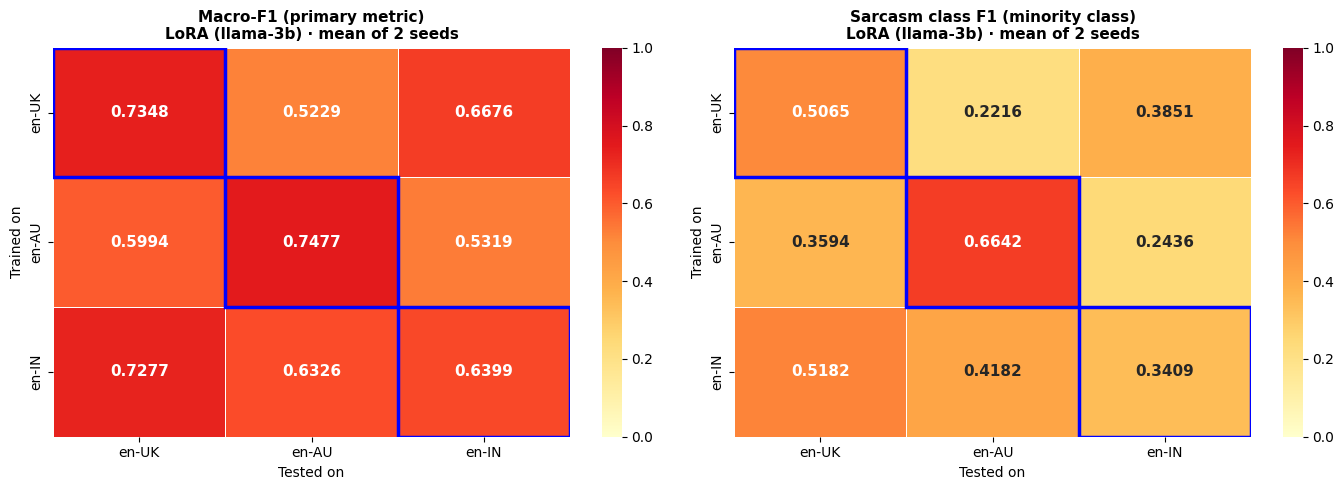

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, m, title in zip(
    axes, [matrix_macro, matrix_sarc],
    ["Macro-F1 (primary metric)", "Sarcasm class F1 (minority class)"]
):
    sns.heatmap(
        m.astype(float), annot=True, fmt=".4f",
        cmap="YlOrRd", vmin=0, vmax=1, linewidths=0.5, ax=ax,
        annot_kws={"size": 11, "weight": "bold"},
    )
    ax.set_title(f"{title}\nLoRA ({MODEL_KEY}) · mean of 2 seeds",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Tested on")
    ax.set_ylabel("Trained on")
    for i in range(len(VARIETIES)):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor="blue", lw=2.5))

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cross_variety_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()

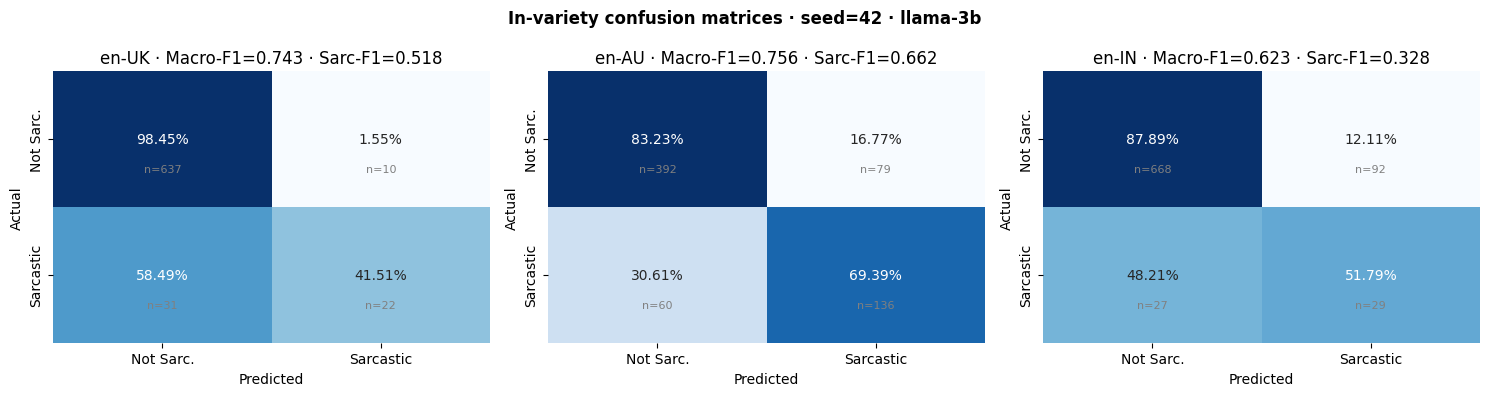

In [21]:
# confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"In-variety confusion matrices · seed=42 · {MODEL_KEY}",
             fontweight="bold", fontsize=12)

for ax, variety in zip(axes, VARIETIES):
    data = all_eval[variety][variety][42]
    cm = confusion_matrix(data["y_true"], data["y_pred"])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt=".2%", cmap="Blues",
        xticklabels=["Not Sarc.", "Sarcastic"],
        yticklabels=["Not Sarc.", "Sarcastic"],
        ax=ax, cbar=False,
    )
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.72, f"n={cm[i,j]}",
                    ha="center", va="center", fontsize=8, color="gray")

    f1 = all_eval[variety][variety][42]["macro_f1"]
    sc = all_eval[variety][variety][42]["f1_class1"]
    ax.set_title(f"{variety} · Macro-F1={f1:.3f} · Sarc-F1={sc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Export results for the report

In [22]:
rows = []
for tv in VARIETIES:
    for tv2 in VARIETIES:
        rec = {"trained_on": tv, "tested_on": tv2}
        rec.update(avg[tv][tv2])
        rows.append(rec)

results_df = pd.DataFrame(rows)
results_df.to_csv(os.path.join(RESULTS_DIR, "cross_variety_results.csv"), index=False)
print(f"Saved: {RESULTS_DIR}/cross_variety_results.csv")
print(results_df.to_string(index=False))

Saved: /user/HS401/mf01425/Documents/coursework nlp/NLP-sequence-classification/results/cross_variety_results.csv
trained_on tested_on  macro_f1_mean  macro_f1_std  precision_mean  precision_std  recall_mean  recall_std  f1_class0_mean  f1_class0_std  f1_class1_mean  f1_class1_std
     en-UK     en-UK         0.7348        0.0084          0.7707         0.0498       0.7160      0.0162          0.9631         0.0057          0.5065         0.0111
     en-UK     en-AU         0.5229        0.0299          0.6427         0.0076       0.5470      0.0149          0.8242         0.0033          0.2216         0.0630
     en-UK     en-IN         0.6676        0.0302          0.6816         0.0656       0.6736      0.0062          0.9502         0.0155          0.3851         0.0450
     en-AU     en-UK         0.5994        0.0205          0.6080         0.0075       0.8353      0.0064          0.8394         0.0205          0.3594         0.0205
     en-AU     en-AU         0.7477        0.0

In [23]:
for variety in VARIETIES:
    print(f"\n {variety} (in-variety, seed=42)")
    print(all_eval[variety][variety][42]["report"])


 en-UK (in-variety, seed=42)
               precision    recall  f1-score   support

Not Sarcastic     0.9536    0.9845    0.9688       647
    Sarcastic     0.6875    0.4151    0.5176        53

     accuracy                         0.9414       700
    macro avg     0.8205    0.6998    0.7432       700
 weighted avg     0.9334    0.9414    0.9347       700


 en-AU (in-variety, seed=42)
               precision    recall  f1-score   support

Not Sarcastic     0.8673    0.8323    0.8494       471
    Sarcastic     0.6326    0.6939    0.6618       196

     accuracy                         0.7916       667
    macro avg     0.7499    0.7631    0.7556       667
 weighted avg     0.7983    0.7916    0.7943       667


 en-IN (in-variety, seed=42)
               precision    recall  f1-score   support

Not Sarcastic     0.9612    0.8789    0.9182       760
    Sarcastic     0.2397    0.5179    0.3277        56

     accuracy                         0.8542       816
    macro avg     0.60